## Tarea 2: Redes Neuronales — Soluciones

1. Considera una red neuronal con los siguientes paráametros: 

$\{\phi_0, \phi_1, \phi_2, \phi_3, \theta_{10},\theta_{11}, \theta_{20}, \theta_{21}, \theta_{30}, \theta_{31} \} = \{−0.23, −1.3, 1.3, 0.66, −0.2, 0.4, −0.9, 0.9, 1.1, −0.7\}$

Recrea las siguientes gráficas cambiando la función de activación por las siguientes: 

1. $heaviside(z) = \begin{cases}
         0 & z < 0\\
         1 & z \geq 0
        \end{cases} $
2. $tanh(z)$ 
3.  $rect(z) = \begin{cases}
         0 & z < 0\\
         1 & 0 \leq z \leq 1\\
         0 & z > 1
        \end{cases} $

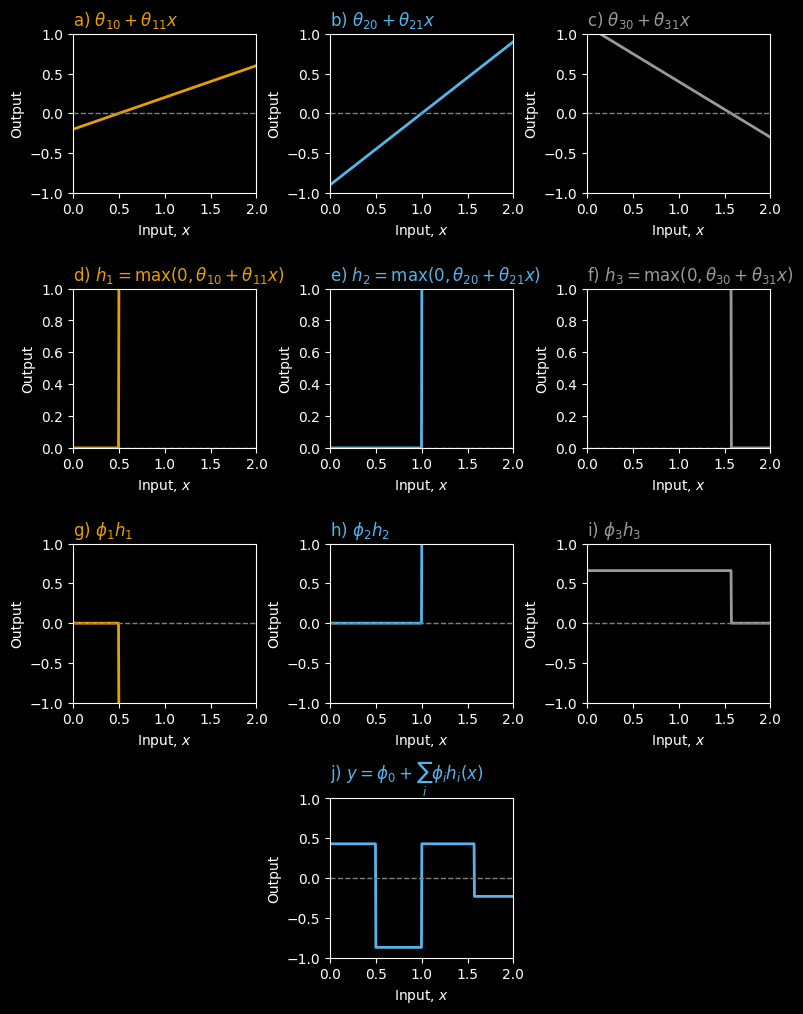

In [1]:
##### HEAVISIDE: 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Definimos los parámetros 
phi0, phi1, phi2, phi3 = -0.23, -1.3, 1.3, 0.66
theta10, theta11 = -0.2,  0.4
theta20, theta21 = -0.9,  0.9
theta30, theta31 =  1.1, -0.7
x = np.linspace(0, 2, 500)

# 2. Calculamos cada unidad oculta antes de activación: l_i(x) = θ_i0 + θ_i1 * x
l1 = theta10 + theta11 * x
l2 = theta20 + theta21 * x
l3 = theta30 + theta31 * x

# 3. Calculamos la función de activación: h_i(x) = max(0, ℓ_i(x))
h1 = (l1 >= 0).astype(float)
h2 = (l2 >= 0).astype(float)
h3 = (l3 >= 0).astype(float)

# 4. Ponderamos las activaciones: φ_i * h_i(x)
w1 = phi1 * h1
w2 = phi2 * h2
w3 = phi3 * h3

# 5. Resultado de la red: y(x) = φ₀ + Σ φ_i h_i(x)
y = phi0 + w1 + w2 + w3

# 6) Graficamos: 
plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.4)
def zero_line(ax):
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
for i, (ℓ, col, title) in enumerate(zip(
    [l1, l2, l3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["a) $\\theta_{10}+\\theta_{11}x$",
     "b) $\\theta_{20}+\\theta_{21}x$",
     "c) $\\theta_{30}+\\theta_{31}x$"]
  )):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(x, ℓ, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (h, col, title) in enumerate(zip(
    [h1, h2, h3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["d) $h_1=\\max(0,\\theta_{10}+\\theta_{11}x)$",
     "e) $h_2=\\max(0,\\theta_{20}+\\theta_{21}x)$",
     "f) $h_3=\\max(0,\\theta_{30}+\\theta_{31}x)$"]
  )):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(x, h, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(0,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (w, col, title) in enumerate(zip(
    [w1, w2, w3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["g) $\\phi_1 h_1$",
     "h) $\\phi_2 h_2$",
     "i) $\\phi_3 h_3$"]
  )):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(x, w, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
ax = fig.add_subplot(gs[3, 1])
ax.plot(x, y, color="#56B4E9", linewidth=2)
zero_line(ax)
ax.set_xlim(0,2); ax.set_ylim(-1,1)
ax.set_title("j) $y = \\phi_0 + \\sum_i \\phi_i h_i(x)$", loc='left', color="#56B4E9", fontsize=12)
ax.set_ylabel("Output")
ax.set_xlabel("Input, $x$")
ax.grid(False)

plt.show()

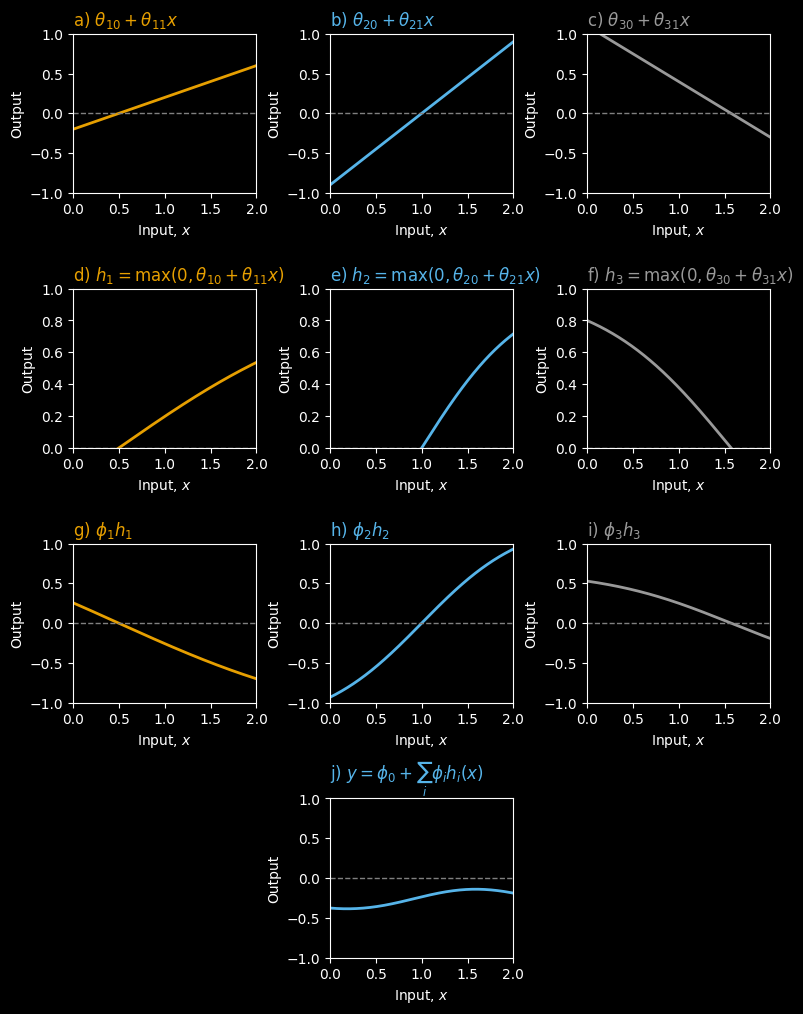

In [2]:
##### tangente hiperbolica: 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Definimos los parámetros 
phi0, phi1, phi2, phi3 = -0.23, -1.3, 1.3, 0.66
theta10, theta11 = -0.2,  0.4
theta20, theta21 = -0.9,  0.9
theta30, theta31 =  1.1, -0.7
x = np.linspace(0, 2, 500)

# 2. Calculamos cada unidad oculta antes de activación: l_i(x) = θ_i0 + θ_i1 * x
l1 = theta10 + theta11 * x
l2 = theta20 + theta21 * x
l3 = theta30 + theta31 * x

# 3. Calculamos la función de activación: h_i(x) = max(0, ℓ_i(x))
h1 = np.tanh(l1)
h2 = np.tanh(l2)
h3 = np.tanh(l3)

# 4. Ponderamos las activaciones: φ_i * h_i(x)
w1 = phi1 * h1
w2 = phi2 * h2
w3 = phi3 * h3

# 5. Resultado de la red: y(x) = φ₀ + Σ φ_i h_i(x)
y = phi0 + w1 + w2 + w3

# 6) Graficamos: 
plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.4)
def zero_line(ax):
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
for i, (ℓ, col, title) in enumerate(zip(
    [l1, l2, l3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["a) $\\theta_{10}+\\theta_{11}x$",
     "b) $\\theta_{20}+\\theta_{21}x$",
     "c) $\\theta_{30}+\\theta_{31}x$"]
  )):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(x, ℓ, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (h, col, title) in enumerate(zip(
    [h1, h2, h3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["d) $h_1=\\max(0,\\theta_{10}+\\theta_{11}x)$",
     "e) $h_2=\\max(0,\\theta_{20}+\\theta_{21}x)$",
     "f) $h_3=\\max(0,\\theta_{30}+\\theta_{31}x)$"]
  )):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(x, h, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(0,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (w, col, title) in enumerate(zip(
    [w1, w2, w3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["g) $\\phi_1 h_1$",
     "h) $\\phi_2 h_2$",
     "i) $\\phi_3 h_3$"]
  )):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(x, w, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
ax = fig.add_subplot(gs[3, 1])
ax.plot(x, y, color="#56B4E9", linewidth=2)
zero_line(ax)
ax.set_xlim(0,2); ax.set_ylim(-1,1)
ax.set_title("j) $y = \\phi_0 + \\sum_i \\phi_i h_i(x)$", loc='left', color="#56B4E9", fontsize=12)
ax.set_ylabel("Output")
ax.set_xlabel("Input, $x$")
ax.grid(False)

plt.show()

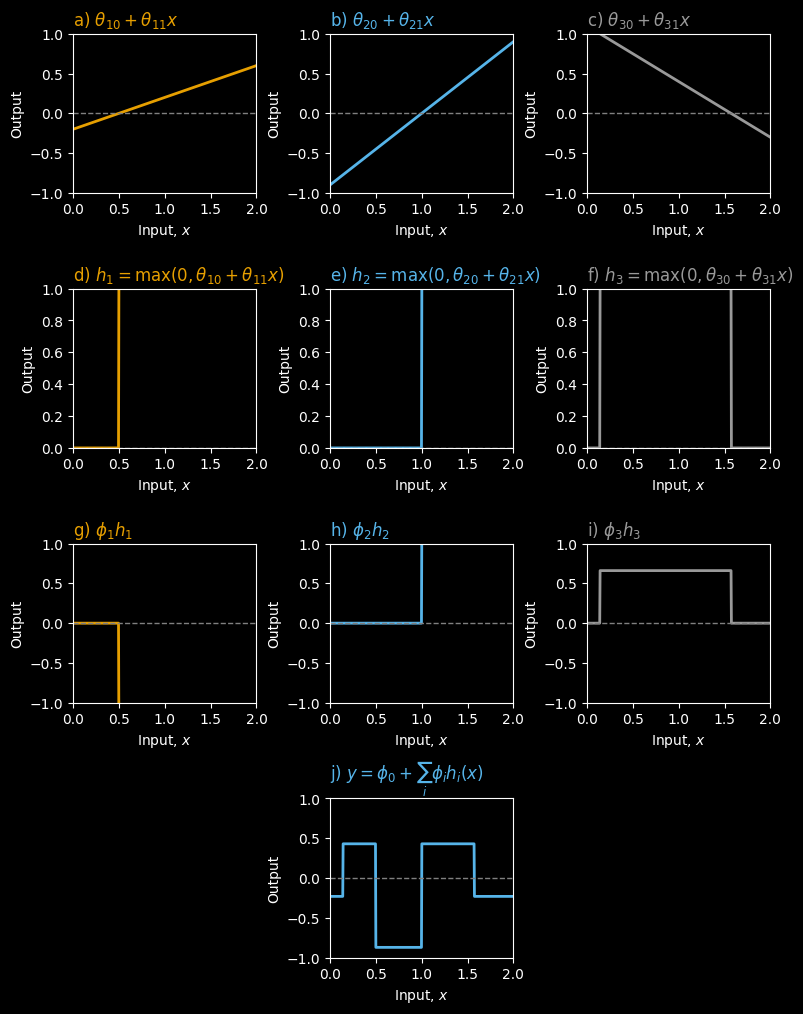

In [3]:
##### RECT: 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Definimos los parámetros 
phi0, phi1, phi2, phi3 = -0.23, -1.3, 1.3, 0.66
theta10, theta11 = -0.2,  0.4
theta20, theta21 = -0.9,  0.9
theta30, theta31 =  1.1, -0.7
x = np.linspace(0, 2, 500)

# 2. Calculamos cada unidad oculta antes de activación: l_i(x) = θ_i0 + θ_i1 * x
l1 = theta10 + theta11 * x
l2 = theta20 + theta21 * x
l3 = theta30 + theta31 * x


# 3. definimos la funcion de activacion 

def rect(z):
    return np.where((z >= 0) & (z <= 1), 1.0, 0.0)


# 3. Calculamos la función de activación: h_i(x) = max(0, ℓ_i(x))
h1 = rect(l1)
h2 = rect(l2)
h3 = rect(l3)

# 4. Ponderamos las activaciones: φ_i * h_i(x)
w1 = phi1 * h1
w2 = phi2 * h2
w3 = phi3 * h3

# 5. Resultado de la red: y(x) = φ₀ + Σ φ_i h_i(x)
y = phi0 + w1 + w2 + w3

# 6) Graficamos: 
plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.4)
def zero_line(ax):
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
for i, (ℓ, col, title) in enumerate(zip(
    [l1, l2, l3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["a) $\\theta_{10}+\\theta_{11}x$",
     "b) $\\theta_{20}+\\theta_{21}x$",
     "c) $\\theta_{30}+\\theta_{31}x$"]
  )):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(x, ℓ, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (h, col, title) in enumerate(zip(
    [h1, h2, h3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["d) $h_1=\\max(0,\\theta_{10}+\\theta_{11}x)$",
     "e) $h_2=\\max(0,\\theta_{20}+\\theta_{21}x)$",
     "f) $h_3=\\max(0,\\theta_{30}+\\theta_{31}x)$"]
  )):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(x, h, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(0,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (w, col, title) in enumerate(zip(
    [w1, w2, w3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["g) $\\phi_1 h_1$",
     "h) $\\phi_2 h_2$",
     "i) $\\phi_3 h_3$"]
  )):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(x, w, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
ax = fig.add_subplot(gs[3, 1])
ax.plot(x, y, color="#56B4E9", linewidth=2)
zero_line(ax)
ax.set_xlim(0,2); ax.set_ylim(-1,1)
ax.set_title("j) $y = \\phi_0 + \\sum_i \\phi_i h_i(x)$", loc='left', color="#56B4E9", fontsize=12)
ax.set_ylabel("Output")
ax.set_xlabel("Input, $x$")
ax.grid(False)

plt.show()

2. Vamos a construir una red neuronal desde 0 en python (gran parte de este código esta arriba) 

     a. Define la función de activación ReLU (tiene que ser una función en python)

     b. Define una red neuronal con 1 input, 1 output y 3 unidades ocultas (tiene que ser una función en python)

     c. Define una función que grafica tu red neuronal, asume que el rango del input es $[0,1]$ y que el rango del output es $[-1,1]$ (tiene que ser una función que recibe input, output, las pre activaciones, las activaciones y los pesos de cada activación). 

     d. Prueba tu código usando los siguientes parámetros: $\theta_{10} = 0.3$, $\theta_{11} = -1.0$, $\theta_{20} = -1.0$, $\theta_{21} = 2.0$, $\theta_{30} = -0.5$, $\theta_{31} = 0.65$, $\phi_0 = -0.3$, $\phi_1 = 2.0$, $\phi_2 = -1.0$, $\phi_3 = 7.0$

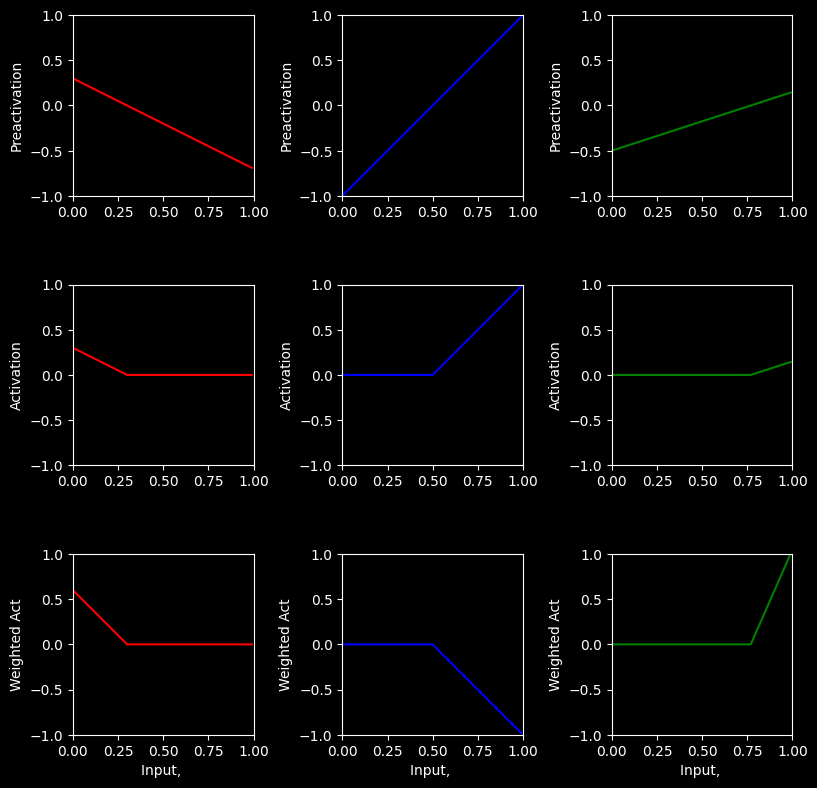

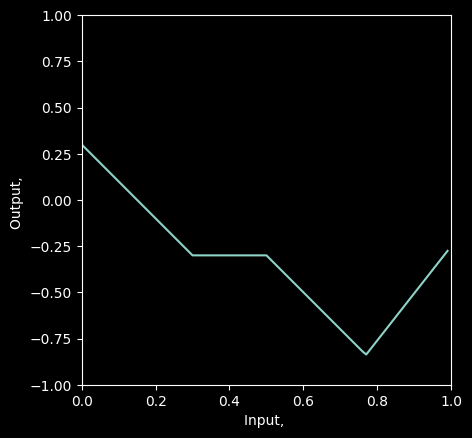

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## a. Definir la función ReLU
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation


## b. Red neuronal con 1 input, 1 ouput y 3 unidades ocultas: 

def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
    # Funciones lineales - pre-activaciones
    pre_1 = theta_10 + theta_11 * x
    pre_2 = theta_20 + theta_21 * x
    pre_3 = theta_30 + theta_31 * x
    # activaciones 
    act_1 = ReLU(pre_1)
    act_2 = ReLU(pre_2)
    act_3 = ReLU(pre_3)
    #Activaciones ponderadas 
    w_act_1 = phi_1*act_1
    w_act_2 = phi_2 * act_2
    w_act_3 = phi_3 * act_3
    # Red 
    y = phi_0 + w_act_1 + w_act_2 + w_act_3 
    return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

## c. Funcion que grafique la red neuronal:
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, ');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, '); ax.set_ylabel('Output, ')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

  ## d. probar la red
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

x = np.arange(0,1,0.01)

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)
     


3. Usando el código que creaste y los parámetros para tu red vamos a evaluar lo siguiente. Para estas preguntas contesta con una oración o dos teoricamente que pasa ademas de correr tu código para ver graficamente que esta pasando con la red. 
    
    a. ¿Qué efecto tiene en la red cambiar $\phi_0$?

    b. ¿Qué efecto tiene multiplicar $phi_1, phi_2, phi_3$ por 0.5?

    c. ¿Qué efecto tiene multiplicar $phi_1$ por -1?

    d. Encuentra un conjunto de parámetros de tal manera que solo haya dos articulaciones en tu red (incluyendo el rango fuera de la gráfica). Existen tres maneras de hacer esto, encuentra al menos 1

    e. Con los parámetros originales el segundo segmento es una linea recta sin pendiente. ¿Cómo cambiarias $\theta_{10}$ para que ningun segmento tenga pendiente cero?


**Respuestas**:

a. Cambiar $\phi_0$, como es el intercepto aumentarlo dezplazara toda la red hacia arriba la misma cantidad en cada x, mientras que disminuirla la dezplaza hacia abajo. 

b. Multiplicar todas las $\phi$'s por 0.5, como son los pesos de cada una de las unidades intermedias, las pendientes de la función lineal por partes va a tener la mitad de pendiente que tenia antes donde esa unidad estaba activa

c. Multiplicar $\phi_1$ por -1 cambia de dirección la articulación de la primera activación

d. Hay tres maneras de hacer esto: 

i. Matar una unidad oculta haciendo que $\phi_i = 0$, entonces solo tendremos dos articulaciones

ii. Mover una unidad fuera del rango de tal manera que $\phi_{i0} + \phi_{i1} x$ siempre es positivo o negativo va a hacer que $h_i$ sea constante y no agrega una nueva articulación

iii. Que dos thresholds sean iguales esto se logra si los parámetros son los siguientes: $- \frac{\theta_{10}}{\theta_{11}} = - \frac{\theta_{20}}{\theta_{21}}$, asi $h_1$ y $h_2$ se van a encender en la misma x produciendo la misma artciculación. 

e. Podemos $\theta_{20} \geq 0 $ de tal manera que ReLU no le haga nada a esta función 

4. Considera la función de pérdida cuadrática: 

$$L(\phi) = \sum_{i=1}^I(y_i - f(x_i,\phi))^2$$

a. Escribe esta función de pérdida en python 

b. Usando los mismos parámetros que en las dos preguntas anteriores y los datos de entrenamiento de acá abajo: corre tu red en los datos de entrenamiento 

c. Calcula que tan bien o mal lo está haciendo está red 

d. Juega un poco con los parámetros e intenta reducir la función de pérdida. ¿Qué parametro parece más útil para hacer esto? 

In [5]:
#a. funcion de pérdida en python 
def least_squares_loss(y_train, y_predict):
    loss = np.sum((y_train - y_predict) ** 2)
    return loss

#b. 
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# c. Como lo hace esta red: 4.28908...
least_squares_loss(y_train, y)

np.float64(9.38487389111789)